# Optymalizacja Systemu Cyber-Fizycznego (CPS) w Inteligentnej Szklarni
Projekt analizuje dwa modele sterowania doświetlaniem roślin: **Reaktywny** oraz **Zaawansowany (Predykcyjny)**.
Celem jest osiągnięcie wymaganego wskaźnika **DLI (Daily Light Integral)** przy minimalizacji kosztów energii i śladu węglowego.

### Kluczowe parametry:
* **DLI**: Sumaryczna dawka światła [mol/m²/d].
* **PPFD**: Chwilowe natężenie światła [µmol/m²s].
* **CO2 Intensity**: Emisyjność sieci [g/kWh].

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('plants_dataset.csv', parse_dates=['Timestamp'])

Wybieramy rośline: `pomidor(tomato)`

In [45]:
plant_type = 'Tomato'
df_filtered = df[df['Plant_Type'] == plant_type].sort_values('Timestamp')
wybrany_dzien = df_filtered['Timestamp'].dt.date.unique()[0]
test_day_raw = df_filtered[df_filtered['Timestamp'].dt.date == wybrany_dzien].copy()
full_day_range = pd.DataFrame({'Hour': range(24)})

test_day = pd.merge(full_day_range, test_day_raw, on='Hour', how='left')

test_day['Sunlight_Actual'] = test_day['Sunlight_Actual'].fillna(0)
test_day['Sunlight_Forecast'] = test_day['Sunlight_Forecast'].fillna(0)
mean_price = test_day['Price_PLN_kWh'].mean()
test_day['Price_PLN_kWh'] = test_day['Price_PLN_kWh'].fillna(mean_price)
test_day['Target_DLI'] = test_day['Target_DLI'].ffill().bfill()
test_day['Max_Threshold_Lux'] = test_day['Max_Threshold_Lux'].ffill().bfill()

print(f"Liczba punktów po uzupełnieniu: {len(test_day)}")

Liczba punktów po uzupełnieniu: 24


## Model Zaawansowany (Knowledge-Based)
Model ten wykorzystuje dane historyczne i prognozy, aby zaplanować doświetlanie w najtańszych i "najczystszych" (Low CO2) godzinach.

In [ ]:
def smart_optimizer(row, dli_accumulated, hours_left):
    """
    Decyduje o mocy lamp na podstawie zapotrzebowania, prognozy i ceny.
    """
    # Cel do osiągnięcia
    target_remaining = max(0, row['Target_DLI'] - dli_accumulated)
    
    if target_remaining <= 0:
        return 0, 0  # Cel osiągnięty - wyłączamy lampy

    # Ile światła dostaniemy ze słońca teraz
    current_sun_dli = (row['Sunlight_Actual'] * 3600) / 1_000_000
    
    # Predykcja: ile słońca dostaniemy jeszcze dzisiaj
    expected_future_sun = (row['Sunlight_Forecast'] * min(hours_left, 5) * 3600) / 1_000_000
    
    led_power = 0
    # Decyzja CPS: Włączamy jeśli jest "tanio" lub jeśli to "ostatnia szansa" na cel
    is_cheap = row['Price_PLN_kWh'] < 0.65
    is_last_chance = hours_left < 6 and (target_remaining > expected_future_sun)

    if is_cheap or is_last_chance:
        # Obliczamy bezpieczną moc (fizyczna granica rośliny)
        max_safe_led = max(0, row['Max_Threshold_Lux'] - row['Sunlight_Actual'])
        
        # Obliczamy moc potrzebną, by nie świecić mocniej niż trzeba
        needed_now_ppfd = (target_remaining * 1_000_000) / 3600
        
        led_power = min(max_safe_led, needed_now_ppfd, 400) # 400 to max moc lampy

    led_dli = (led_power * 3600) / 1_000_000
    return round(led_power, 2), round(led_dli, 4)

### Symulacja doby

In [ ]:
# Inicjalizacja wyników
dli_sum = 0
results = []

for i, row in test_day.iterrows():
    hours_left = 24 - row['Hour']
    led_p, l_dli = smart_optimizer(row, dli_sum, hours_left)
    sun_dli = (row['Sunlight_Actual'] * 3600) / 1_000_000
    dli_sum += (sun_dli + l_dli)
    
    results.append({
        'Hour': row['Hour'],
        'LED_Power': led_p,
        'Accumulated_DLI': dli_sum,
        'Price': row['Price_PLN_kWh']
    })

res_df = pd.DataFrame(results)

## Analiza Wyników i Test Odporności
Poniżej sprawdzamy, jak system poradził sobie z realizacją planu. 
W kolejnym kroku wprowadzimy **"zepsute dane"** (np. Sunlight_Actual = 0 w południe), aby zobaczyć reakcję mechanizmów weryfikacji (Kamera vs Czujnik).

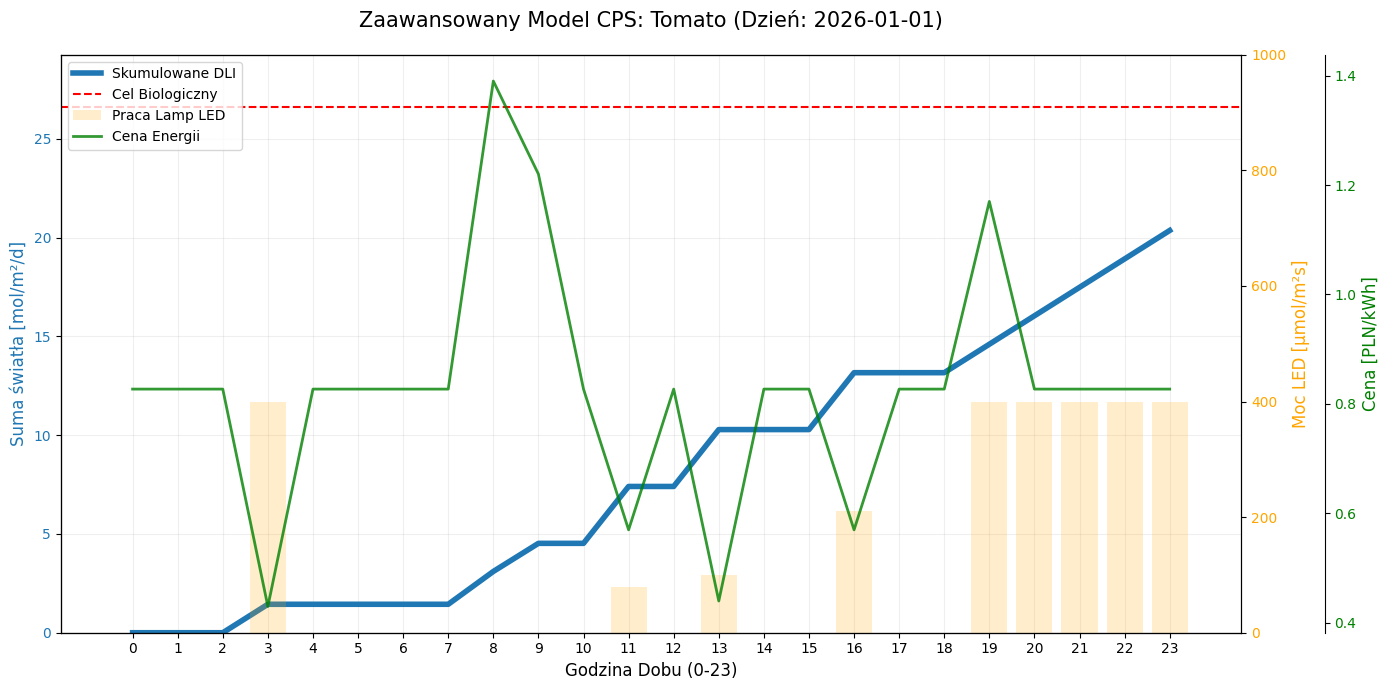

In [52]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# DLI
ax1.plot(res_df['Hour'], res_df['Accumulated_DLI'], color='#1f77b4', linewidth=4, label='Skumulowane DLI')
ax1.axhline(y=test_day['Target_DLI'].iloc[0], color='red', linestyle='--', label='Cel Biologiczny')
ax1.set_ylabel('Suma światła [mol/m²/d]', color='#1f77b4', fontsize=12)
ax1.set_xlabel('Godzina Dobu (0-23)', fontsize=12)
ax1.set_xticks(range(0, 24))
ax1.set_ylim(0, max(res_df['Accumulated_DLI'].max(), test_day['Target_DLI'].iloc[0]) * 1.1)
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# MOC LED 
ax2 = ax1.twinx()
ax2.bar(res_df['Hour'], res_df['LED_Power'], alpha=0.2, color='orange', label='Praca Lamp LED')
ax2.set_ylabel('Moc LED [µmol/m²s]', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_ylim(0, 1000) 

#CENA
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(res_df['Hour'], res_df['Price'], color='green', alpha=0.8, linewidth=2, label='Cena Energii')
ax3.set_ylabel('Cena [PLN/kWh]', color='green', fontsize=12)
ax3.tick_params(axis='y', labelcolor='green')

plt.title(f'Zaawansowany Model CPS: {plant_type} (Dzień: {wybrany_dzien})', fontsize=15, pad=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

ax1.grid(alpha=0.2)
fig.tight_layout()
plt.show()

### Proste obliczenie kosztów

In [53]:
total_energy_kwh = res_df['LED_Power'].sum() * (1/1000) # uproszczone przeliczenie
total_cost = (res_df['LED_Power'] * res_df['Price']).sum() * (1/1000)

print(f"Całkowity koszt doświetlania tej doby: {total_cost:.2f} PLN")
print(f"Zużycie energii: {total_energy_kwh:.2f} kWh")
print(f"Uzyskane DLI: {res_df['Accumulated_DLI'].iloc[-1]:.2f} / {test_day['Target_DLI'].iloc[0]:.2f}")

Całkowity koszt doświetlania tej doby: 2.17 PLN
Zużycie energii: 2.79 kWh
Uzyskane DLI: 20.36 / 26.60
